In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving machine_downtime.csv to machine_downtime.csv


In [5]:
df=pd.read_csv('machine_downtime.csv')
df.head(10)

,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
0,DT0001,2025-09-03,M08,10.2,Kerusakan Elektrikal,70.5,98.2,Malam,NaN
1,DT0002,2025-11-11,M10,6.4,Kerusakan Mekanis,57.3,77.6,Malam,1149.0
2,DT0003,2025-09-21,M05,7.2,Kerusakan Mekanis,59.9,43.4,Pagi,820.0
3,DT0004,2025-08-23,M06,12.9,Kerusakan Mekanis,79.8,69.8,Siang,1757.0
4,DT0005,2026-01-14,M07,8.5,Kerusakan Mekanis,64.4,100.0,Pagi,787.0
5,DT0006,2025-10-03,M07,8.6,Kerusakan Mekanis,64.8,67.4,Malam,944.0
6,DT0007,2025-12-25,M06,12.9,Kerusakan Mekanis,79.9,100.0,Pagi,NaN
7,DT0008,2025-12-12,M04,11.3,Kerusakan Mekanis,74.3,87.4,Malam,1285.0
8,DT0009,2025-08-27,M09,6.1,Kekurangan Bahan Baku,56.0,65.9,Pagi,909.0
9,DT0010,2025-09-04,M08,10.7,Pergantian Alat (Tooling Change),72.1,55.8,Malam,1828.0


In [6]:
df.shape

(520, 9)

In [10]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Kejadian                  520 non-null    object 
 1   Tanggal_Kejadian             520 non-null    object 
 2   ID_Mesin                     520 non-null    object 
 3   Usia_Mesin_Tahun             520 non-null    float64
 4   Penyebab_Downtime            520 non-null    object 
 5   Durasi_Downtime_Menit        520 non-null    float64
 6   Beban_Kerja_Harian_Persen    520 non-null    float64
 7   Shift_Kejadian               520 non-null    object 
 8   Biaya_Perbaikan_Ribu_Rupiah  427 non-null    float64
dtypes: float64(4), object(5)
memory usage: 36.7+ KB


,0
ID_Kejadian,object
Tanggal_Kejadian,object
ID_Mesin,object
Usia_Mesin_Tahun,float64
Penyebab_Downtime,object
Durasi_Downtime_Menit,float64
Beban_Kerja_Harian_Persen,float64
Shift_Kejadian,object
Biaya_Perbaikan_Ribu_Rupiah,float64


In [11]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
Biaya_Perbaikan_Ribu_Rupiah,93,17.884615


In [12]:
df['Biaya_Perbaikan_Ribu_Rupiah'] = df.groupby('Penyebab_Downtime')['Biaya_Perbaikan_Ribu_Rupiah'].transform(lambda x: x.fillna(x.median()))


In [13]:
df.isnull().sum()

,0
ID_Kejadian,0
Tanggal_Kejadian,0
ID_Mesin,0
Usia_Mesin_Tahun,0
Penyebab_Downtime,0
Durasi_Downtime_Menit,0
Beban_Kerja_Harian_Persen,0
Shift_Kejadian,0
Biaya_Perbaikan_Ribu_Rupiah,0


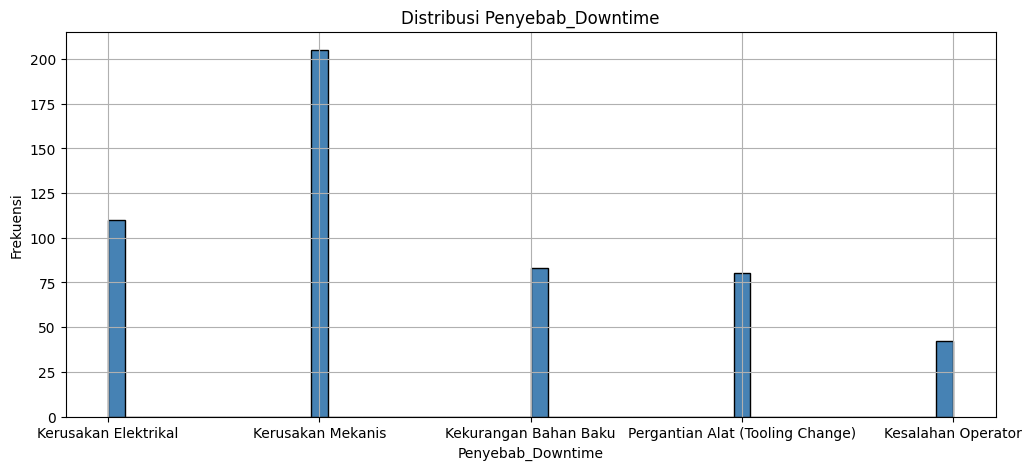

In [15]:
plt.figure(figsize=(12, 5))
df['Penyebab_Downtime'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi Penyebab_Downtime')
plt.xlabel('Penyebab_Downtime')
plt.ylabel('Frekuensi')
plt.show()

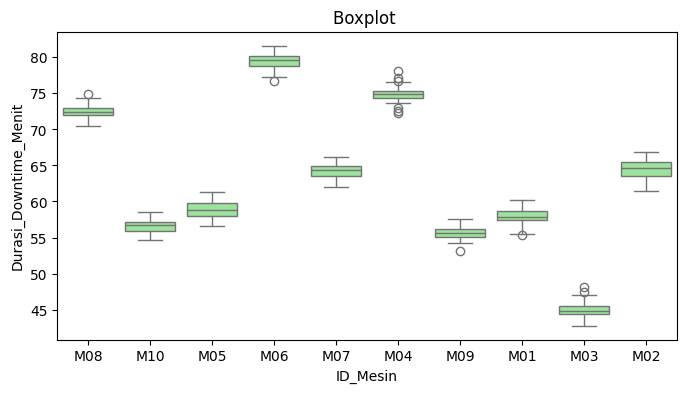

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df,x='ID_Mesin',y='Durasi_Downtime_Menit', color='lightgreen')
plt.title('Boxplot ')
plt.show()

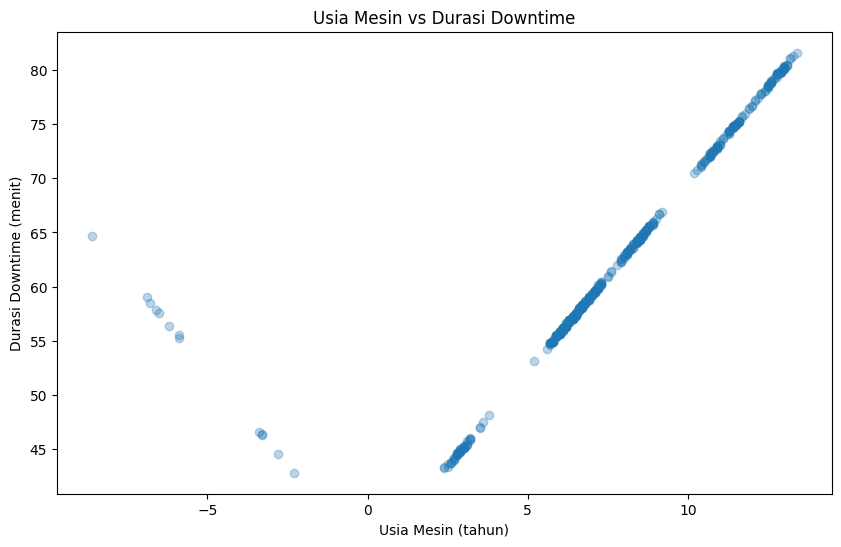

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Usia_Mesin_Tahun'], df['Durasi_Downtime_Menit'], alpha=0.3)
plt.xlabel('Usia Mesin (tahun)')
plt.ylabel('Durasi Downtime (menit)')
plt.title('Usia Mesin vs Durasi Downtime')
plt.show()